# Azimuthal sectors: `rebin1d` instead of many `integrate1d`

Fibres, textured materials and single-crystal-like samples give diffraction images where the
intensity depends on the azimuthal angle χ. Describing such a sample means extracting one
powder pattern *per azimuthal sector*, not a single one averaged over the whole ring.

The straightforward way of doing this is to call `integrate1d` once per sector, with the
`azimuth_range` parameter. It works, but every sector costs a complete traversal of the image:
the four and a half million pixels of an Eiger 4M are read, corrected and histogrammed as many
times as there are sectors, even though each sector only keeps a fraction of them.

The alternative is to perform a *single* fine 2D integration and to collapse the azimuthal bins
of each sector afterwards, with `Integrate2dResult.rebin1d()`. The image is then traversed once,
and a sector is obtained by summing a few rows of the 2D result — a few hundred thousand values
instead of a few million pixels.

This tutorial compares the two approaches, in accuracy and in speed, on a Kevlar fibre dataset
recorded with an Eiger 4M detector.

In [1]:
%matplotlib inline

In [2]:
import time
import numpy
from matplotlib.pyplot import subplots
import fabio
from silx.resources import ExternalResources
import pyFAI
from pyFAI.gui import jupyter

start_time = time.perf_counter()
print(f"Using pyFAI version {pyFAI.version}")

Using pyFAI version 2026.9.1-dev0


## The dataset

The data are available on `http://www.silx.org/pub/pyFAI/kevlar/`: a tomography scan of a Kevlar
fibre, 2000 frames of an Eiger 4M detector. The file weights 2 GB: the first call downloads it,
the following ones reuse the local copy.

In [3]:
downloader = ExternalResources("kevlar", "http://www.silx.org/pub/pyFAI/kevlar/")
fimg = fabio.open(downloader.getfile("kevla_tomo_68_data_000001.h5"))
frame = fimg.data
print(f"{fimg.nframes} frames of shape {frame.shape} ({frame.dtype}), "
      f"i.e. {frame.size / 1e6:.1f} Mpixel per frame")

2000 frames of shape (2167, 2070) (uint16), i.e. 4.5 Mpixel per frame


The geometry of the experiment was calibrated beforehand; the PONI is given here as a
dictionary, which `pyFAI.load` accepts as well as a `.poni` file.

In [4]:
poni = {"version": 3,
        "wavelength": 9.21815574169e-11,
        "dist": 0.162558188965,
        "poni1": 0.0963249893098,
        "poni2": 0.0863684201475,
        "rot1": 0.00459634184823,
        "rot2": 0.000845922278262,
        "rot3": -2.85542293455e-09,
        "detector": "Eiger4M",
        "detector_config": {"orientation": 3}}
ai = pyFAI.load(poni)
print(ai)

Detector Eiger 4M	 PixelSize= 75µm, 75µm	 BottomRight (3)
Wavelength= 0.921816 Å
SampleDetDist= 1.625582e-01 m	PONI= 9.632499e-02, 8.636842e-02 m	rot1=0.004596  rot2=0.000846  rot3=-0.000000 rad
DirectBeamDist= 162.560 mm	Center: x=1141.617, y=1286.167 pix	Tilt= 0.268° tiltPlanRotation= 169.572° λ= 0.922Å


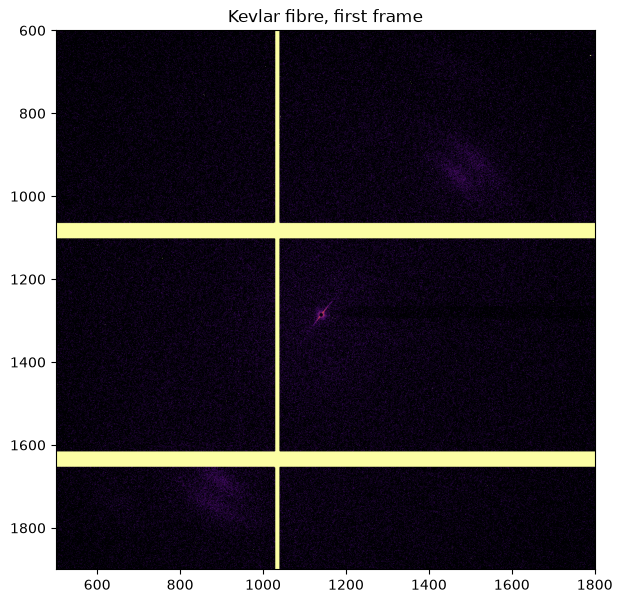

In [5]:
fig, ax = subplots(figsize=(7, 7))
jupyter.display(frame, label="Kevlar fibre, first frame", ax=ax)
ax.set_xlim(500, 1800)
ax.set_ylim(1900, 600)
pass

## The sample is textured

A 2D integration (the *cake*) shows it immediately: the rings are not uniform, they are made of
arcs. The intensity of a given ring depends on where one looks along χ — exactly the information
a single 1D integration averages away.

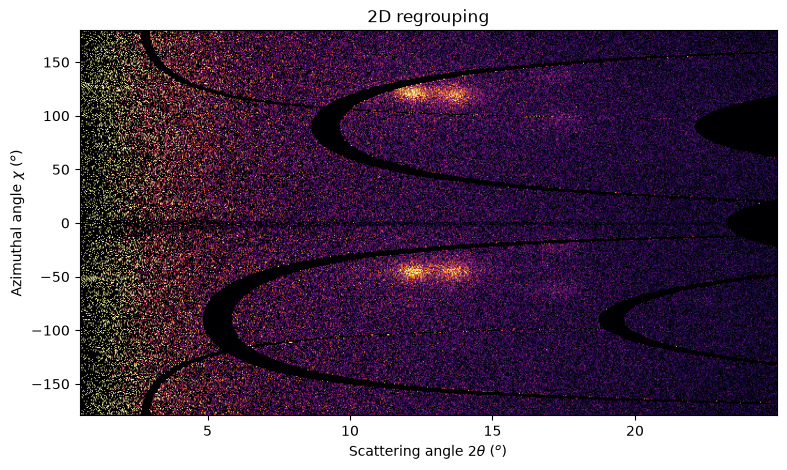

In [6]:
unit = "2th_deg"
method = ("no", "csr", "cython")  # no pixel splitting: see the discussion below
radial_range = (0.5, 25.0)
npt_rad = 1000
npt_azim = 360

res2d = ai.integrate2d(frame, npt_rad, npt_azim, method=method, unit=unit,
                       radial_range=radial_range, azimuth_range=(-180, 180),
                       error_model="poisson")
fig, ax = subplots(figsize=(9, 5))
jupyter.plot2d(res2d, ax=ax)
# a few isolated Bragg spots are orders of magnitude above the rings: clip the
# colour scale, otherwise everything else is black
ax.images[0].set_clim(0, numpy.nanpercentile(res2d.intensity, 99.5))
pass

The two arcs around 2θ = 13° are the Kevlar rings. Averaging them over that radial band gives
the orientation distribution of the fibre: two lobes, 170° apart, three times above the
background. A single `integrate1d` over the whole azimuth would return their average and lose
that information.

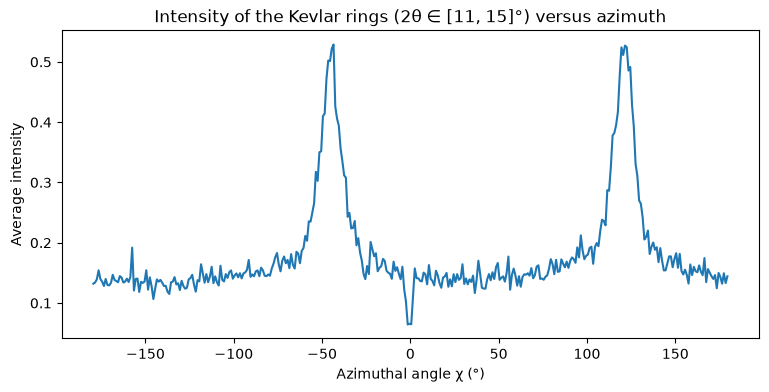

In [7]:
band = numpy.logical_and(res2d.radial > 11, res2d.radial < 15)
profile = (res2d.sum_signal[:, band].sum(axis=1) /
           res2d.sum_normalization[:, band].sum(axis=1))
fig, ax = subplots(figsize=(9, 4))
ax.plot(res2d.azimuthal, profile)
ax.set_xlabel("Azimuthal angle χ (°)")
ax.set_ylabel("Average intensity")
ax.set_title("Intensity of the Kevlar rings (2θ ∈ [11, 15]°) versus azimuth")
pass

## Two ways of extracting azimuthal sectors

Let us cut the azimuthal range into sectors of equal width and extract one powder pattern per
sector, first with `integrate1d`, then with `rebin1d`.

The engines are called once before every measurement, so that the timings compare the steady
state and not the construction of the sparse matrices.

In [8]:
NSECTORS = 8
edges = numpy.linspace(-180, 180, NSECTORS + 1)
sectors = [(float(low), float(high)) for low, high in zip(edges[:-1], edges[1:])]
print(f"{NSECTORS} sectors of {360 / NSECTORS:.0f}°: {sectors}")

8 sectors of 45°: [(-180.0, -135.0), (-135.0, -90.0), (-90.0, -45.0), (-45.0, 0.0), (0.0, 45.0), (45.0, 90.0), (90.0, 135.0), (135.0, 180.0)]


In [9]:
def by_integrate1d(image, sectors):
    "One call to integrate1d per azimuthal sector"
    return [ai.integrate1d(image, npt_rad, method=method, unit=unit,
                           radial_range=radial_range, azimuth_range=sector,
                           error_model="poisson")
            for sector in sectors]

def by_rebin1d(image, sectors):
    "One fine 2D integration, then one rebin1d per azimuthal sector"
    res2d = ai.integrate2d(image, npt_rad, npt_azim, method=method, unit=unit,
                           radial_range=radial_range, azimuth_range=(-180, 180),
                           error_model="poisson")
    return [res2d.rebin1d(azimuth_range=sector) for sector in sectors]

# warm-up: build the sparse matrices once
by_integrate1d(frame, sectors[:1])
by_rebin1d(frame, sectors[:1])
pass

In [10]:
t0 = time.perf_counter()
reference = by_integrate1d(frame, sectors)
t_1d = time.perf_counter() - t0
print(f"{NSECTORS} x integrate1d: {t_1d * 1000:.0f} ms, i.e. {t_1d / NSECTORS * 1000:.0f} ms per sector")

8 x integrate1d: 1662 ms, i.e. 208 ms per sector


In [11]:
t0 = time.perf_counter()
rebinned = by_rebin1d(frame, sectors)
t_rebin = time.perf_counter() - t0
print(f"1 x integrate2d + {NSECTORS} x rebin1d: {t_rebin * 1000:.0f} ms")
print(f"Speed-up: {t_1d / t_rebin:.1f}x")

1 x integrate2d + 8 x rebin1d: 101 ms
Speed-up: 16.5x


### Where does the time go?

pyFAI caches the sparse matrix which maps the pixels onto the bins, and reuses it as long as the
integration parameters do not change. Changing `azimuth_range` invalidates that cache, so each
new sector pays for a rebuild — but that is only part of the story: even when the matrix is
reused, a sector still costs a full pass over the image.

In [12]:
def timeit(function, *args, **kwargs):
    "Return the execution time, in milliseconds"
    t0 = time.perf_counter()
    function(*args, **kwargs)
    return (time.perf_counter() - t0) * 1000

ai.reset()  # drop every cached engine
common = dict(method=method, unit=unit, radial_range=radial_range, error_model="poisson")
print(f"first call, the matrix has to be built:  "
      f"{timeit(ai.integrate1d, frame, npt_rad, azimuth_range=sectors[0], **common):5.0f} ms")
print(f"same sector again, the matrix is cached: "
      f"{timeit(ai.integrate1d, frame, npt_rad, azimuth_range=sectors[0], **common):5.0f} ms")
print(f"another sector, the matrix is rebuilt:   "
      f"{timeit(ai.integrate1d, frame, npt_rad, azimuth_range=sectors[1], **common):5.0f} ms")
print(f"one rebin1d on the 2D result:            "
      f"{timeit(res2d.rebin1d, azimuth_range=sectors[1]):5.2f} ms")
print(f"\n{frame.size / 1e6:.1f} Mpixel are traversed by an integrate1d, against "
      f"{res2d.intensity.size / 1e3:.0f} k values by a rebin1d")

first call, the matrix has to be built:   1169 ms
same sector again, the matrix is cached:   112 ms


another sector, the matrix is rebuilt:     232 ms
one rebin1d on the 2D result:             0.86 ms

4.5 Mpixel are traversed by an integrate1d, against 360 k values by a rebin1d


The irreducible cost of a sector done with `integrate1d` is therefore the traversal of the
image, which no caching can avoid. `rebin1d` works on the 2D result, more than ten times smaller
here, and is three orders of magnitude cheaper.

## Are the two results the same?

They are, provided two conditions are met:

* the boundaries of the sectors fall on boundaries of the azimuthal bins of the 2D integration —
  `rebin1d` can only select whole bins, and reports in `azimuth_range` the range it actually
  covered. Choosing `npt_azim` as a multiple of the number of sectors guarantees this;
* no pixel splitting is used. With `bbox` or `full` splitting, a pixel straddling the limit of a
  sector is shared between the neighbouring bins, and the sharing differs between a 1D
  integration restricted to the sector and a 2D integration followed by a rebinning.

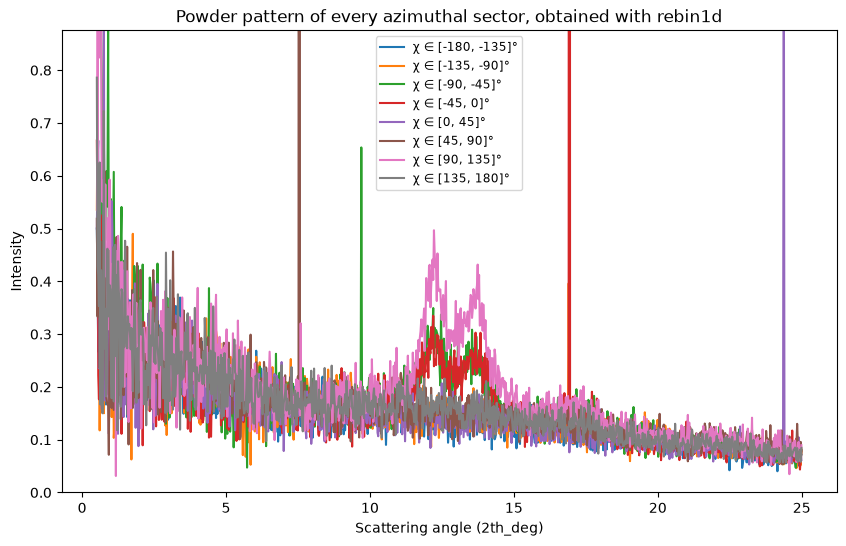

In [13]:
fig, ax = subplots(figsize=(10, 6))
for sector, res in zip(sectors, rebinned):
    ax.plot(res.radial, res.intensity, label=f"χ ∈ [{sector[0]:.0f}, {sector[1]:.0f}]°")
ax.set_ylim(0, numpy.nanpercentile(numpy.concatenate([r.intensity for r in rebinned]), 99.8))
ax.set_xlabel(f"Scattering angle ({unit})")
ax.set_ylabel("Intensity")
ax.set_title("Powder pattern of every azimuthal sector, obtained with rebin1d")
ax.legend(fontsize="small")
pass

In [14]:
for sector, ref, obt in zip(sectors, reference, rebinned):
    assert numpy.allclose(ref.radial, obt.radial)
    delta = numpy.nanmax(abs(ref.intensity - obt.intensity))
    print(f"χ ∈ [{sector[0]:7.1f}, {sector[1]:6.1f}]° -> "
          f"covered {obt.azimuth_range[0]:7.1f} .. {obt.azimuth_range[1]:6.1f}°, "
          f"max |ΔI| = {delta:.3g}")

χ ∈ [ -180.0, -135.0]° -> covered  -180.0 .. -135.0°, max |ΔI| = 0
χ ∈ [ -135.0,  -90.0]° -> covered  -135.0 ..  -90.0°, max |ΔI| = 0
χ ∈ [  -90.0,  -45.0]° -> covered   -90.0 ..  -45.0°, max |ΔI| = 0
χ ∈ [  -45.0,    0.0]° -> covered   -45.0 ..    0.0°, max |ΔI| = 0
χ ∈ [    0.0,   45.0]° -> covered     0.0 ..   45.0°, max |ΔI| = 0
χ ∈ [   45.0,   90.0]° -> covered    45.0 ..   90.0°, max |ΔI| = 0
χ ∈ [   90.0,  135.0]° -> covered    90.0 ..  135.0°, max |ΔI| = 0
χ ∈ [  135.0,  180.0]° -> covered   135.0 ..  180.0°, max |ΔI| = 0


## How does it scale with the number of sectors?

The cost of the `integrate1d` approach is proportional to the number of sectors: one pass over
the image each. The cost of the `rebin1d` approach is dominated by the single 2D integration,
which does not depend on the number of sectors at all.

In [15]:
# the cell above reset the engines: warm them up again before timing
by_integrate1d(frame, sectors[:1])
by_rebin1d(frame, sectors[:1])

counts = (2, 4, 8, 18, 36, 72)
timings = {"integrate1d": [], "rebin1d": []}
for nsec in counts:
    bounds = numpy.linspace(-180, 180, nsec + 1)
    sect = [(float(low), float(high)) for low, high in zip(bounds[:-1], bounds[1:])]
    t0 = time.perf_counter()
    by_integrate1d(frame, sect)
    timings["integrate1d"].append(time.perf_counter() - t0)
    t0 = time.perf_counter()
    by_rebin1d(frame, sect)
    timings["rebin1d"].append(time.perf_counter() - t0)
    print(f"{nsec:3d} sectors: integrate1d {timings['integrate1d'][-1]:6.3f} s, "
          f"rebin1d {timings['rebin1d'][-1]:6.3f} s, "
          f"speed-up {timings['integrate1d'][-1] / timings['rebin1d'][-1]:5.1f}x")

  2 sectors: integrate1d  0.451 s, rebin1d  0.102 s, speed-up   4.4x


  4 sectors: integrate1d  0.724 s, rebin1d  0.100 s, speed-up   7.3x


  8 sectors: integrate1d  1.333 s, rebin1d  0.102 s, speed-up  13.1x


 18 sectors: integrate1d  3.287 s, rebin1d  0.114 s, speed-up  28.9x


 36 sectors: integrate1d  6.690 s, rebin1d  0.093 s, speed-up  71.7x


 72 sectors: integrate1d 11.005 s, rebin1d  0.104 s, speed-up 105.6x


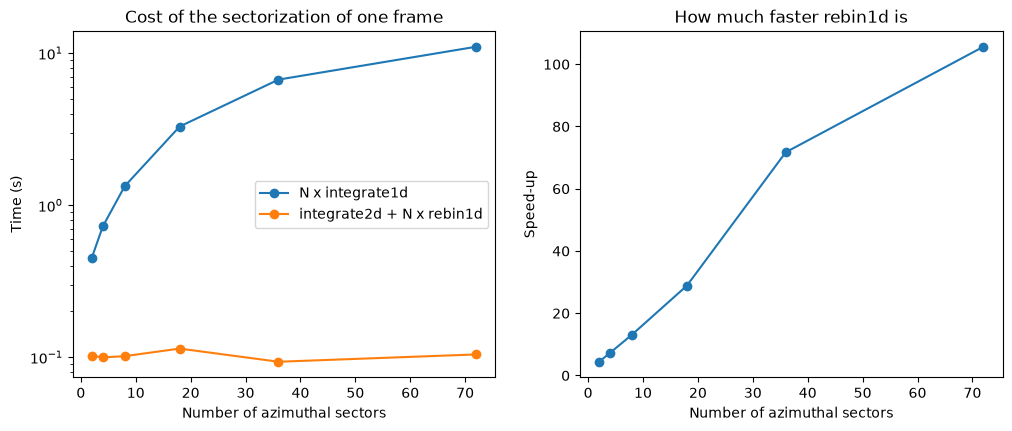

In [16]:
fig, ax = subplots(1, 2, figsize=(12, 4.5))
ax[0].plot(counts, timings["integrate1d"], "o-", label="N x integrate1d")
ax[0].plot(counts, timings["rebin1d"], "o-", label="integrate2d + N x rebin1d")
ax[0].set_xlabel("Number of azimuthal sectors")
ax[0].set_ylabel("Time (s)")
ax[0].set_yscale("log")
ax[0].set_title("Cost of the sectorization of one frame")
ax[0].legend()
ax[1].plot(counts, numpy.array(timings["integrate1d"]) / numpy.array(timings["rebin1d"]), "o-")
ax[1].set_xlabel("Number of azimuthal sectors")
ax[1].set_ylabel("Speed-up")
ax[1].set_title("How much faster rebin1d is")
pass

## On a series of frames

One may object that the sparse matrix of a given sector could be reused from one frame to the
next, by looping over the sectors on the outside and over the frames on the inside. As measured
above, this saves the rebuild of the matrix but not the traversal of the image, which is what
actually costs. Below, a small series is processed both ways, with the loop order which is the
most favourable to `integrate1d`.

In [17]:
NFRAMES = 10
SECTORS = 12
bounds = numpy.linspace(-180, 180, SECTORS + 1)
series_sectors = [(float(low), float(high)) for low, high in zip(bounds[:-1], bounds[1:])]
frames = [fimg.get_frame(i).data for i in range(NFRAMES)]
print(f"{NFRAMES} frames of {frames[0].nbytes / 1e6:.0f} MB loaded in memory")

10 frames of 9 MB loaded in memory


In [18]:
t0 = time.perf_counter()
per_sector = [[ai.integrate1d(image, npt_rad, azimuth_range=sector, **common)
               for image in frames]
              for sector in series_sectors]
t_series_1d = time.perf_counter() - t0
print(f"integrate1d, sectors outside: {t_series_1d:6.2f} s "
      f"({t_series_1d / NFRAMES * 1000:.0f} ms per frame)")

integrate1d, sectors outside:  14.24 s (1424 ms per frame)


In [19]:
t0 = time.perf_counter()
per_frame = [by_rebin1d(image, series_sectors) for image in frames]
t_series_rebin = time.perf_counter() - t0
print(f"integrate2d + rebin1d:        {t_series_rebin:6.2f} s "
      f"({t_series_rebin / NFRAMES * 1000:.0f} ms per frame)")
print(f"Speed-up: {t_series_1d / t_series_rebin:.1f}x")

integrate2d + rebin1d:          1.72 s (172 ms per frame)
Speed-up: 8.3x


In [20]:
# the two series hold the same curves, transposed
delta = max(numpy.nanmax(abs(per_sector[j][i].intensity - per_frame[i][j].intensity))
            for i in range(NFRAMES) for j in range(SECTORS))
print(f"largest deviation over the {NFRAMES * SECTORS} curves: {delta:.3g}")

largest deviation over the 120 curves: 0


## Restricting the radial range as well

`rebin1d` also accepts a `radial_range`. Unlike `integrate1d`, it does not re-bin: it keeps the
bins of the 2D integration, hence their size, and simply drops those falling outside the
requested range. The number of points of the result therefore depends on the requested range.

Both ranges are expressed in the unit of the matching axis of the 2D result, and the range which
was actually covered is reported by the `radial_range` and `azimuth_range` attributes.

radial: 408 bins covering 5.01 .. 15.00 2th_deg
azimuthal: collapsed over -45.0 .. 45.0°


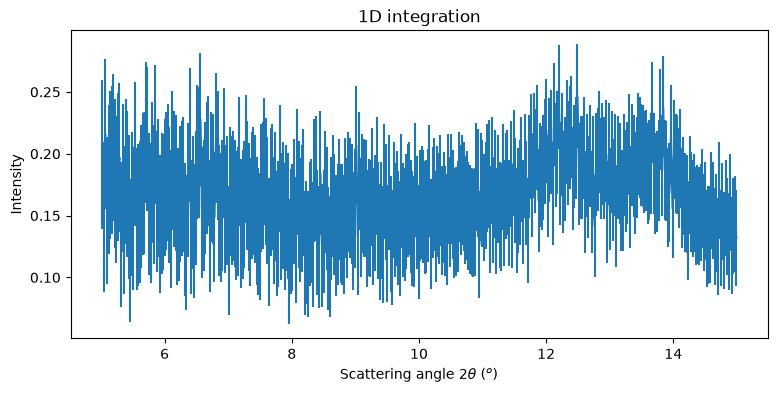

In [21]:
zoom = res2d.rebin1d(radial_range=(5, 15), azimuth_range=(-45, 45))
print(f"radial: {zoom.radial.size} bins covering {zoom.radial_range[0]:.2f} .. "
      f"{zoom.radial_range[1]:.2f} {unit}")
print(f"azimuthal: collapsed over {zoom.azimuth_range[0]:.1f} .. {zoom.azimuth_range[1]:.1f}°")

fig, ax = subplots(figsize=(9, 4))
jupyter.plot1d(zoom, ax=ax)
pass

## Conclusion

Extracting azimuthal sectors with `rebin1d` is one to two orders of magnitude faster than calling
`integrate1d` once per sector, and the two give the same numbers as long as the sectors are
aligned on the azimuthal bins of the 2D integration and no pixel splitting is involved.

The rule of thumb: as soon as more than one or two azimuthal sectors are needed on a given image,
integrate once in 2D with a fine azimuthal sampling, then rebin. `npt_azim` sets the granularity
at which the sectors can be defined; picking a multiple of the number of sectors guarantees that
their boundaries fall on bin boundaries.

`rebin1d` is also the tool of choice to explore a dataset interactively: once the 2D integration
is computed, any sector is available in a few milliseconds.

In [22]:
print(f"Total execution time: {time.perf_counter() - start_time:.1f} s")

Total execution time: 56.2 s
